In [7]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
import os
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)
root_dir = "/content/gdrive/My Drive/AI-neuroscience-knowledge-discovery/Projects/Project: Neuroscience and AI in Africa/Intersection of NS & CS/Synthesis/PLOS computational biology/analysis/"
os.listdir(root_dir)

Mounted at /content/gdrive


['years.xlsx',
 'years.tiff',
 'years.ipynb',
 'map.ipynb',
 'countries_by_region_and_dataset.png']

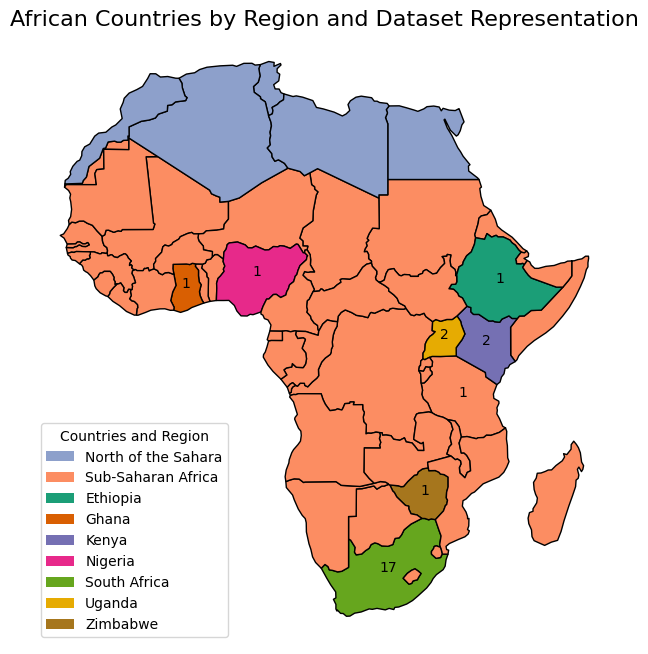

In [9]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# -----------------------------
# Country data
# -----------------------------
countries = [
    "Kenya","Kenya",
    "Uganda","Uganda",
    "Nigeria",
    "Zimbabwe",
    "Ghana",
    "Tanzania",
    "Ethiopia",
    "South Africa","South Africa","South Africa","South Africa","South Africa",
    "South Africa","South Africa","South Africa","South Africa","South Africa",
    "South Africa","South Africa","South Africa","South Africa","South Africa",
    "South Africa","South Africa"
]

df = pd.DataFrame({"country": countries})

# Count occurrences
counts = df.value_counts("country").reset_index()
counts.columns = ["name", "count"]

# -----------------------------
# Load Africa map
# -----------------------------
world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)

africa = world[world["CONTINENT"] == "Africa"]

# -----------------------------
# Define regions
# -----------------------------
north_africa = [
    "Morocco", "Algeria", "Tunisia",
    "Libya", "Egypt", "Western Sahara"
]

# Merge counts
africa = africa.merge(counts, how="left", left_on="NAME", right_on="name")
africa["count"] = africa["count"].fillna(0)

# -----------------------------
# Colour scheme
# -----------------------------
country_colors = {
    "Ethiopia": "#1b9e77",
    "Ghana": "#d95f02",
    "Kenya": "#7570b3",
    "Nigeria": "#e7298a",
    "South Africa": "#66a61e",
    "Uganda": "#e6ab02",
    "Zimbabwe": "#a6761d"
}

north_color = "#8da0cb"        # North of Sahara
sub_sahara_color = "#fc8d62"   # Sub-Saharan Africa

def assign_color(row):
    if row["NAME"] in north_africa:
        return north_color
    elif row["NAME"] in country_colors:
        return country_colors[row["NAME"]]
    else:
        return sub_sahara_color

africa["plot_color"] = africa.apply(assign_color, axis=1)

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(7.5, 8.75)) # width_inches = 7.5   # 19.05 cm, and height_inches = 8.75 # 22.23 cm

africa.plot(
    ax=ax,
    color=africa["plot_color"],
    edgecolor="black"
)

# Annotate counts
for _, row in africa.iterrows():
    if row["count"] > 0:
        ax.annotate(
            text=int(row["count"]),
            xy=(row.geometry.centroid.x, row.geometry.centroid.y),
            ha="center",
            fontsize=10
        )

# -----------------------------
# Legend
# -----------------------------
legend_elements = [
    Patch(facecolor=north_color, label="North of the Sahara"),
    Patch(facecolor=sub_sahara_color, label="Sub-Saharan Africa"),
    Patch(facecolor=country_colors["Ethiopia"], label="Ethiopia"),
    Patch(facecolor=country_colors["Ghana"], label="Ghana"),
    Patch(facecolor=country_colors["Kenya"], label="Kenya"),
    Patch(facecolor=country_colors["Nigeria"], label="Nigeria"),
    Patch(facecolor=country_colors["South Africa"], label="South Africa"),
    Patch(facecolor=country_colors["Uganda"], label="Uganda"),
    Patch(facecolor=country_colors["Zimbabwe"], label="Zimbabwe"),
]

ax.legend(
    handles=legend_elements,
    loc="lower left",
    title="Countries and Region"
)

# -----------------------------
# Styling
# -----------------------------
ax.set_title("African Countries by Region and Dataset Representation", fontsize=16)
ax.axis("off")

plt.savefig(root_dir+"countries_by_region_and_dataset.tiff", dpi=600, bbox_inches="tight",  pil_kwargs={"compression": "tiff_lzw"})
plt.show()
